In [50]:
import pandas as pd
import numpy as np

In [51]:
films = pd.read_csv("movies.csv")
films.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [130]:
pop = films[["original_title", "popularity"]]
pop_sort = popularity.sort_values("popularity", ascending=False)
pop_sort


,original_title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
...,...,...
4625,Midnight Cabaret,0.001389
4118,Hum To Mohabbat Karega,0.001186
4727,Penitentiary,0.001117
3361,Alien Zone,0.000372


In [ ]:
rating = films[["original_title","vote_average"]]
rating_sort = rating.sort_values("vote_average", ascending = False)
rating_sort


,original_title,vote_average
4662,Little Big Top,10.0
3519,Stiff Upper Lips,10.0
4045,"Dancer, Texas Pop. 81",10.0
4247,Me You and Five Bucks,10.0
3992,Sardaarji,9.5
...,...,...
4444,Le bonheur d'Elza,0.0
4400,Sparkler,0.0
1464,Black Water Transit,0.0
4716,The Blood of My Brother: A Story of Death in Iraq,0.0


In [133]:
merge = pd.merge(rating, popularity) 
merge


,original_title,vote_average,popularity
0,Little Big Top,10.0,0.092100
1,Stiff Upper Lips,10.0,0.356495
2,"Dancer, Texas Pop. 81",10.0,0.376662
3,Me You and Five Bucks,10.0,0.094105
4,Sardaarji,9.5,0.296981
...,...,...,...
4802,Le bonheur d'Elza,0.0,0.007254
4803,Sparkler,0.0,0.547654
4804,Black Water Transit,0.0,0.126738
4805,The Blood of My Brother: A Story of Death in Iraq,0.0,0.005256


In [88]:
pop_sort[pop_sort["original_title"] == "Little Big Top"]

,original_title,popularity
4662,Little Big Top,0.0921


<Axes: xlabel='popularity', ylabel='vote_average'>

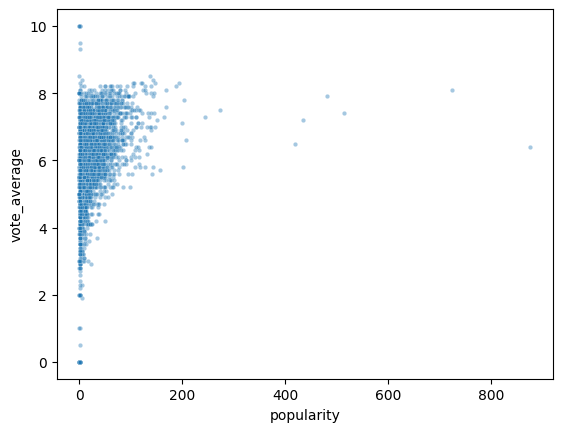

In [136]:
import seaborn as sns

x = films["popularity"]
y = films["vote_average"]

sns.scatterplot(data=films, x="popularity", y="vote_average",
                alpha=0.4, s=10)


In [125]:
diff = merge["vote_average"] - merge["popularity"]
diff = pd.DataFrame({
    "title": merge["original_title"],
    "differenced": diff
    })
diff

,title,differenced
0,Little Big Top,9.907900
1,Stiff Upper Lips,9.643505
2,"Dancer, Texas Pop. 81",9.623338
3,Me You and Five Bucks,9.905895
4,Sardaarji,9.203019
...,...,...
4802,Le bonheur d'Elza,-0.007254
4803,Sparkler,-0.547654
4804,Black Water Transit,-0.126738
4805,The Blood of My Brother: A Story of Death in Iraq,-0.005256


In [138]:
#high rating, low popularity
diff.sort_values("differenced", ascending=False).head(20)

,title,differenced
0,Little Big Top,9.907900
3,Me You and Five Bucks,9.905895
1,Stiff Upper Lips,9.643505
2,"Dancer, Texas Pop. 81",9.623338
4,Sardaarji,9.203019
7,There Goes My Baby,8.462927
5,One Man's Hero,8.389471
12,Counting,8.006413
69,Dolphins and Whales: Tribes of the Ocean,7.958349
64,Rise of the Entrepreneur: The Search for a Bet...,7.947058


In [ ]:
#high popularity low rating
diff.sort_values("differenced", ascending=True).head(20)

,title,differenced
2104,Minions,-869.181305
47,Interstellar,-716.147784
415,Deadpool,-507.169956
114,Guardians of the Galaxy,-473.198624
604,Mad Max: Fury Road,-427.078564
1732,Jurassic World,-412.208552
288,Pirates of the Caribbean: The Curse of the Bla...,-264.472889
453,Dawn of the Planet of the Apes,-236.491743
1728,The Hunger Games: Mockingjay - Part 1,-199.627151
3339,Terminator Genisys,-196.242635


In [152]:
films["director"].value_counts().head(20)


director
Steven Spielberg        27
Woody Allen             21
Clint Eastwood          20
Martin Scorsese         20
Spike Lee               16
Ridley Scott            16
Robert Rodriguez        16
Steven Soderbergh       15
Renny Harlin            15
Oliver Stone            14
Tim Burton              14
Robert Zemeckis         13
Ron Howard              13
Barry Levinson          13
Joel Schumacher         13
Brian De Palma          12
Tony Scott              12
Francis Ford Coppola    12
Kevin Smith             12
Michael Bay             12
Name: count, dtype: int64

In [ ]:
#relation between budget and popularity
rela = films["budget"].corr(films["popularity"])
rela


np.float64(0.5054139990665322)

Since there is a relation of 0.505 there is a relation that the bigger the budget the more popular a film is.

In [ ]:
films.groupby("director")["popularity"].mean().sort_values(ascending=False).head(20) #ranking directors by popularity



director
Kyle Balda               875.581305
Tim Miller               514.569956
Colin Trevorrow          221.947277
Damien Chazelle          192.528841
Christopher Nolan        185.373245
James Gunn               170.210157
Chris Buck               165.125366
Alan Taylor              150.771115
Pierre Coffin            125.372489
Brenda Chapman           125.114374
Chris Williams           122.790234
Wes Ball                 122.488529
Robert Stromberg         110.620647
Pete Docter              109.224490
Joss Whedon              108.038933
David Robert Mitchell    100.876794
Dean DeBlois             100.213910
Francis Lawrence          99.498063
Gore Verbinski            95.845222
Alex Garland              95.130041
Name: popularity, dtype: float64